In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Amazon.csv')

**TASK_1:-DATA_CLEANING_AND_PREPARATION**

In [4]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,NaN,First page,5,...,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   643 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()

In [8]:
df.isnull().sum()

,0
Timestamp,0
age,0
Gender,0
Purchase_Frequency,0
Purchase_Categories,0
Personalized_Recommendation_Frequency,0
Browsing_Frequency,0
Product_Search_Method,157
Search_Result_Exploration,0
Customer_Reviews_Importance,0


In [9]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='object')


In [10]:
df['Product_Search_Method'] = df['Product_Search_Method'].fillna('Keyword')

In [11]:
df['Product_Search_Method'] = df['Product_Search_Method'].str.title()

In [12]:
df['Customer_Reviews_Importance'] = df['Customer_Reviews_Importance'].astype(float)

In [13]:
df['Rating_Accuracy'] = df['Rating_Accuracy'].astype(float)

In [14]:
df['Shopping_Satisfaction'] = df['Shopping_Satisfaction'].astype(float)

In [15]:
 df.dtypes

,0
Timestamp,object
age,int64
Gender,object
Purchase_Frequency,object
Purchase_Categories,object
Personalized_Recommendation_Frequency,object
Browsing_Frequency,object
Product_Search_Method,object
Search_Result_Exploration,object
Customer_Reviews_Importance,float64


In [16]:
df.to_csv('Amazon_Task_1_Data_cleaned.csv', index=False)

**TASK_2:-DESCRIPTIVE_BEHAVIOR_ANALYSIS**

In [17]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2.0,...,Yes,Moderately,No,2,Sometimes,4.0,4.0,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3.0,...,Yes,Heavily,Yes,1,Sometimes,4.0,5.0,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2.0,...,Yes,Heavily,Sometimes,5,No,5.0,3.0,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2.0,...,Yes,Occasionally,No,3,Yes,1.0,2.0,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Keyword,First page,5.0,...,Yes,Rarely,No,2,Yes,1.0,2.0,Quick delivery,Irrelevant product suggestions,683642


In [18]:
df['age'].describe()

,age
count,800.000000
mean,35.170000
std,18.916485
min,3.000000
25%,19.000000
50%,35.500000
75%,51.000000
max,67.000000


In [19]:
df['Gender'].value_counts()

,count
Gender,
Male,209
Others,202
Female,197
Prefer not to say,192


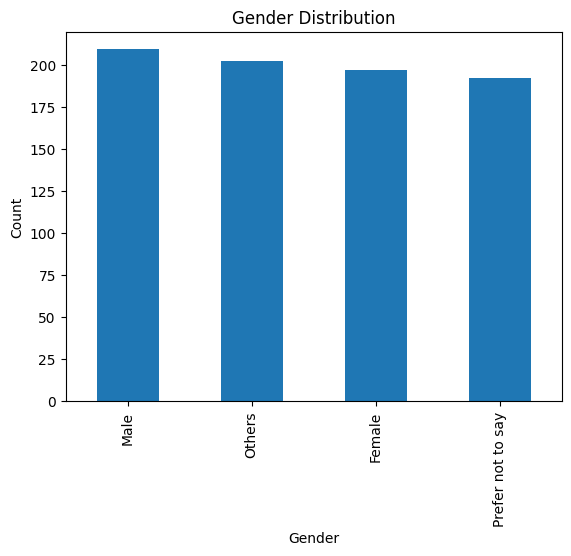

In [20]:
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [21]:
df['Purchase_Frequency'].value_counts()

,count
Purchase_Frequency,
Once a month,168
Multiple times a week,159
Once a week,159
Few times a month,158
Less than once a month,156


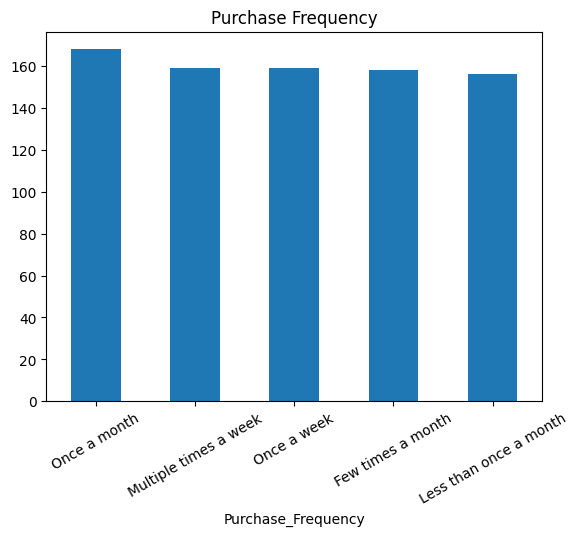

In [22]:
df['Purchase_Frequency'].value_counts().plot(kind='bar')
plt.title('Purchase Frequency')
plt.xticks(rotation=30)
plt.show()

In [23]:
df['Purchase_Categories'].value_counts()

,count
Purchase_Categories,
Clothing and Fashion;others,39
others,38
Beauty and Personal Care;Clothing and Fashion;others,38
Clothing and Fashion;Home and Kitchen;others,36
Groceries and Gourmet Food;Clothing and Fashion,34
Beauty and Personal Care;Clothing and Fashion,32
Groceries and Gourmet Food;Clothing and Fashion;Home and Kitchen;others,31
Groceries and Gourmet Food;Clothing and Fashion;others,30
Groceries and Gourmet Food;Home and Kitchen;others,30


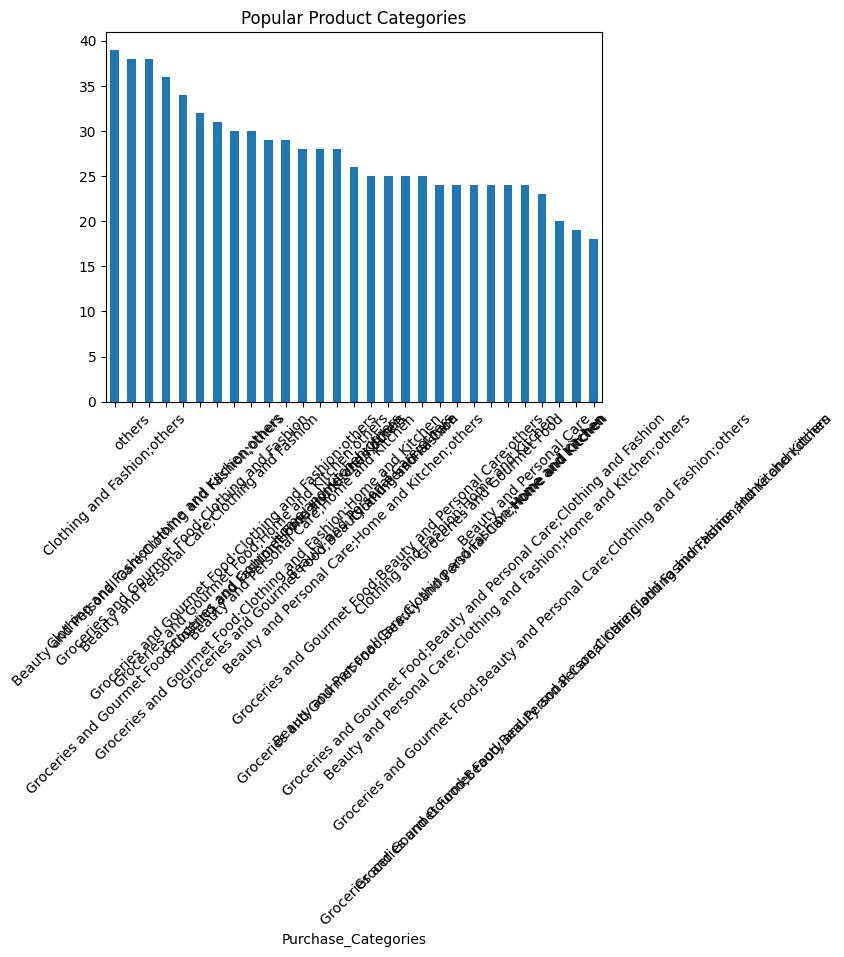

In [24]:
df['Purchase_Categories'].value_counts().plot(kind='bar')
plt.title('Popular Product Categories')
plt.xticks(rotation=45)
plt.show()

In [25]:
df['Product_Search_Method'].value_counts()

,count
Product_Search_Method,
Keyword,327
Categories,163
Filter,161
Others,149


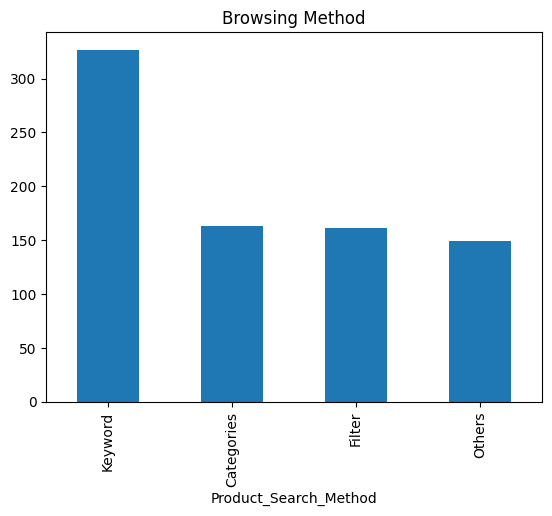

In [26]:
df['Product_Search_Method'].value_counts().plot(kind='bar')
plt.title('Browsing Method')
plt.show()

In [27]:
df['Cart_Abandonment_Factors'].value_counts()

,count
Cart_Abandonment_Factors,
High shipping costs,224
Found a better price elsewhere,206
Changed my mind or no longer need the item,194
others,176


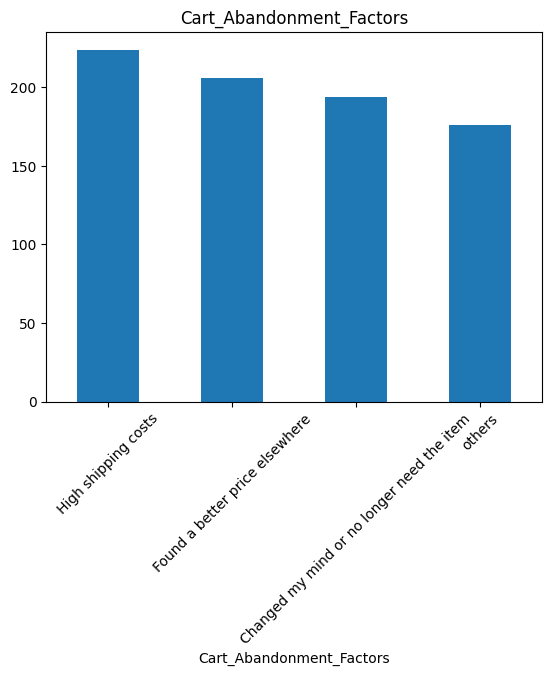

In [28]:
df['Cart_Abandonment_Factors'].value_counts().plot(kind='bar')
plt.title('Cart_Abandonment_Factors')
plt.xticks(rotation=45)
plt.show()

In [29]:
df['Shopping_Satisfaction'].mean()

np.float64(3.0125)

In [30]:
df['Shopping_Satisfaction'].median()

3.0

In [31]:
df['Recommendation_Helpfulness'].unique()

array(['Sometimes', 'No', 'Yes'], dtype=object)

In [32]:
df['Recommendation_Helpfulness'] = df['Recommendation_Helpfulness'].replace({
    'No':0,
    'Sometimes':1,
    'Yes':2
})

/tmp/ipykernel_4117/707207844.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Recommendation_Helpfulness'] = df['Recommendation_Helpfulness'].replace({


In [33]:
df['Recommendation_Helpfulness'].mean()

np.float64(1.01)

In [34]:
df['Recommendation_Helpfulness'].median()

1.0

In [35]:
df['Rating_Accuracy'].mean()

np.float64(2.96875)

In [36]:
df['Rating_Accuracy'].median()

3.0

In [37]:
df.describe()

,age,Customer_Reviews_Importance,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,transaction
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000,800.000000
mean,35.170000,3.058750,2.952500,1.010000,2.968750,3.01250,556906.991250
std,18.916485,1.408111,1.420481,0.815924,1.403651,1.40706,261823.943299
min,3.000000,1.000000,1.000000,0.000000,1.000000,1.00000,101391.000000
25%,19.000000,2.000000,2.000000,0.000000,2.000000,2.00000,332074.750000
50%,35.500000,3.000000,3.000000,1.000000,3.000000,3.00000,563278.500000
75%,51.000000,4.000000,4.000000,2.000000,4.000000,4.00000,780725.250000
max,67.000000,5.000000,5.000000,2.000000,5.000000,5.00000,999892.000000


In [38]:
df.to_csv('Amazon_Task_2_Descriptive_Analysis.csv', index=False)

**TASK_3:-CUSTOMER_SEGMENTATION_AND_PROFILLING**

In [39]:
df['Purchase_Frequency'].unique()

array(['Less than once a month', 'Once a week', 'Once a month',
       'Few times a month', 'Multiple times a week'], dtype=object)

In [40]:
df['Shopping_Satisfaction'].unique()

array([4., 5., 3., 2., 1.])

In [41]:
conditions = [

    (df['Purchase_Frequency'] == 'Once a week') &
    (df['Shopping_Satisfaction'] >= 4),

    (df['Purchase_Frequency'] == 'Once a month') &
    (df['Shopping_Satisfaction'] >= 3),

    (df['Shopping_Satisfaction'] <= 2)
]

In [42]:
choices = [
    'Frequent Buyer',
    'Occasional Shopper',
    'At-Risk Customer'
]

In [43]:
df['Customer_Profile'] = np.select(conditions, choices, default='Regular Customer')

In [44]:
df['Customer_Profile'].value_counts()

,count
Customer_Profile,
Regular Customer,323
At-Risk Customer,320
Occasional Shopper,97
Frequent Buyer,60


In [45]:
pd.crosstab(df['Customer_Profile'], df['Gender'])

Gender,Female,Male,Others,Prefer not to say
Customer_Profile,,,,
At-Risk Customer,72,93,77,78
Frequent Buyer,15,13,11,21
Occasional Shopper,28,19,25,25
Regular Customer,82,84,89,68


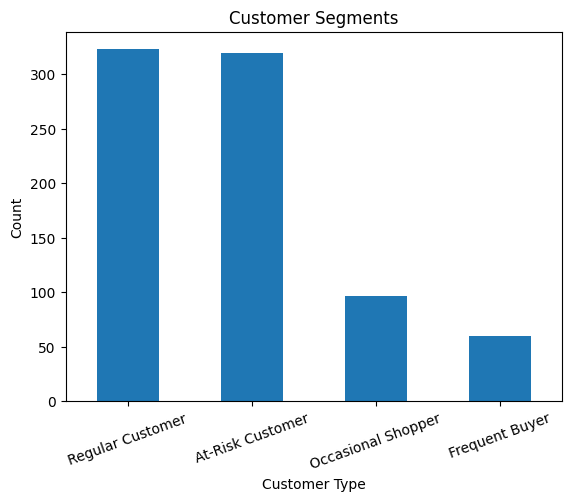

In [46]:
df['Customer_Profile'].value_counts().plot(kind='bar')
plt.title('Customer Segments')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

In [47]:
from sklearn.cluster import KMeans

In [48]:
X = df[['Shopping_Satisfaction', 'Rating_Accuracy']]

In [49]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

In [50]:
df['Cluster'].value_counts()

,count
Cluster,
0,298
1,280
2,222


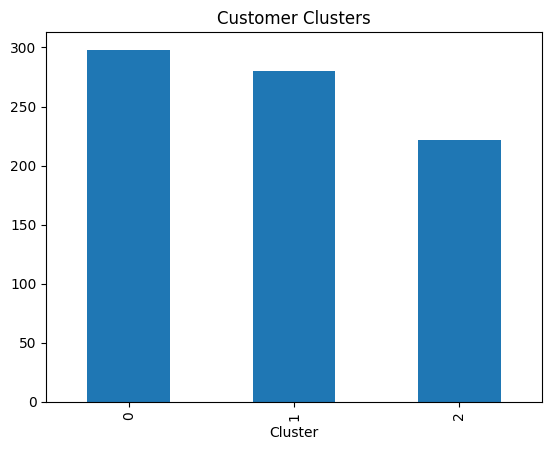

In [51]:
df['Cluster'].value_counts().plot(kind='bar')
plt.title('Customer Clusters')
plt.show()

In [52]:
df.to_csv('Amazon_Task_3_Customer_Segmentation.csv', index=False)

**TASK_4:-RECOMMENDATION_AND_REVIEW_INSIGHTS**

In [53]:
df['Recommendation_Helpfulness'].unique()

array([1, 0, 2])

In [54]:
df.groupby('Recommendation_Helpfulness')['Shopping_Satisfaction'].mean()

,Shopping_Satisfaction
Recommendation_Helpfulness,
0,3.041985
1,2.955224
2,3.040741


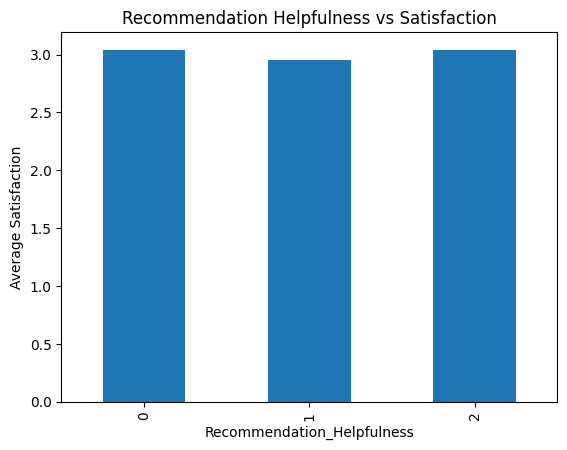

In [55]:
df.groupby('Recommendation_Helpfulness')['Shopping_Satisfaction'].mean().plot(kind='bar')
plt.title('Recommendation Helpfulness vs Satisfaction')
plt.ylabel('Average Satisfaction')
plt.show()

In [56]:
df['Review_Reliability'].unique()

array(['Moderately', 'Heavily', 'Occasionally', 'Rarely', 'Never'],
      dtype=object)

In [57]:
df['Review_Reliability'] = df['Review_Reliability'].replace({
    'Never':0,
    'Rarely':1,
    'Occasionally':2,
    'Moderately':3,
    'Heavily':4
})

/tmp/ipykernel_4117/2402404402.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Review_Reliability'] = df['Review_Reliability'].replace({


In [58]:
df['Review_Reliability'].unique()

array([3, 4, 2, 1, 0])

In [59]:
df.groupby('Review_Reliability')['Rating_Accuracy'].mean()

,Rating_Accuracy
Review_Reliability,
0,2.843373
1,2.920000
2,2.857143
3,3.205128
4,3.023952


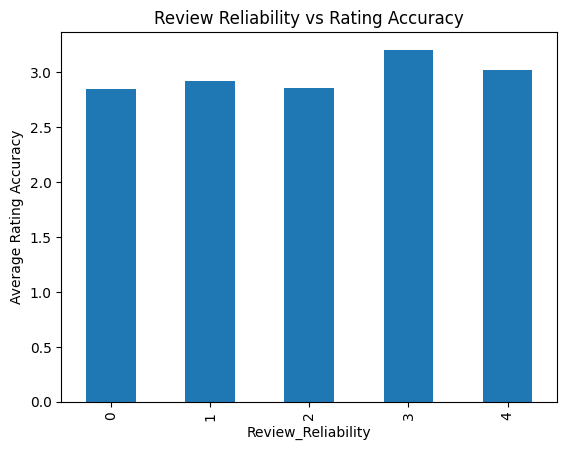

In [60]:
df.groupby('Review_Reliability')['Rating_Accuracy'].mean().plot(kind='bar')
plt.title('Review Reliability vs Rating Accuracy')
plt.ylabel('Average Rating Accuracy')
plt.show()

In [61]:
print(df.columns)

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction', 'Customer_Profile', 'Cluster'],
      dtype='object')


In [62]:
df.columns = df.columns.str.strip()

In [63]:
df = df.loc[:, ~df.columns.duplicated()]

In [64]:
df['Personalized_Recommendation_Frequency'].value_counts()

,count
Personalized_Recommendation_Frequency,
Yes,278
No,272
Sometimes,250


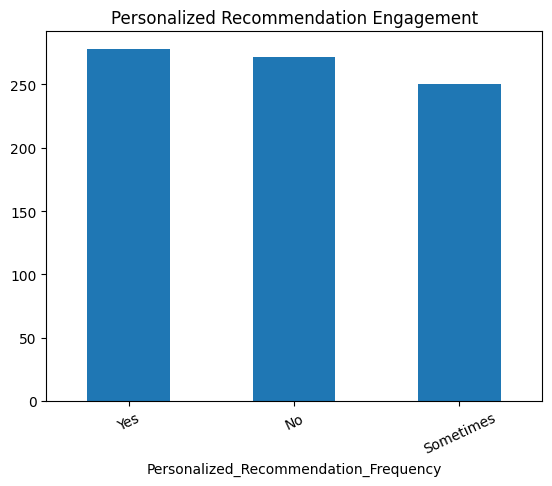

In [65]:
df['Personalized_Recommendation_Frequency'].value_counts().plot(kind='bar')
plt.title('Personalized Recommendation Engagement')
plt.xticks(rotation=25)
plt.show()

In [66]:
df.to_csv('Amazon_Task_4_Recommendation.csv', index=False)

**TASK_5:-VISUALIZATION_AND_REPORTING**

In [67]:
 df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Reliability,Review_Helpfulness,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Customer_Profile,Cluster
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2.0,...,3,No,1,4.0,4.0,Competitive prices,better app interface and lower shipping charges,778242,Regular Customer,0
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3.0,...,4,Yes,1,4.0,5.0,Quick delivery,Scrolling option would be much better than goi...,193482,Frequent Buyer,0
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2.0,...,4,Sometimes,0,5.0,3.0,All the above,Nil,925975,Regular Customer,1
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2.0,...,2,No,2,1.0,2.0,Quick delivery,Quality of product is very poor according to t...,566872,At-Risk Customer,2
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Keyword,First page,5.0,...,1,No,2,1.0,2.0,Quick delivery,Irrelevant product suggestions,683642,At-Risk Customer,2


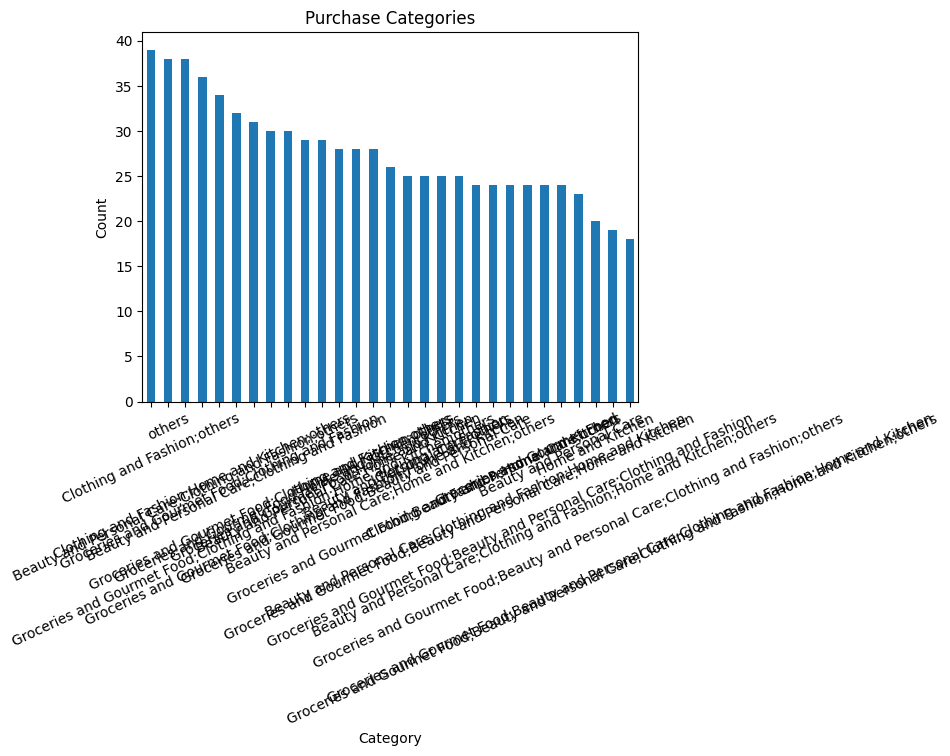

In [69]:
df['Purchase_Categories'].value_counts().plot(kind='bar')
plt.title('Purchase Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=25)
plt.show()

In [70]:
print(df.columns)

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Recommendation_Helpfulness', 'Rating_Accuracy',
       'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas',
       'transaction', 'Customer_Profile', 'Cluster'],
      dtype='object')


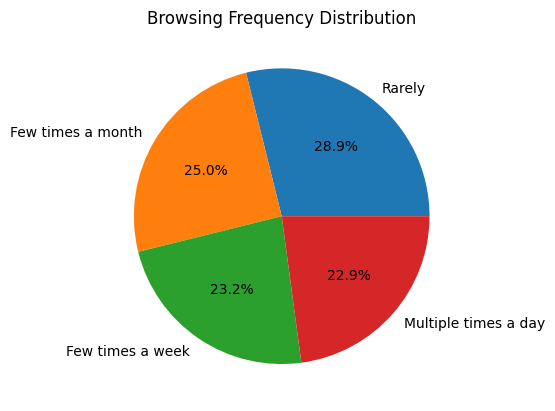

In [71]:
df['Browsing_Frequency'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Browsing Frequency Distribution')
plt.ylabel('')
plt.show()

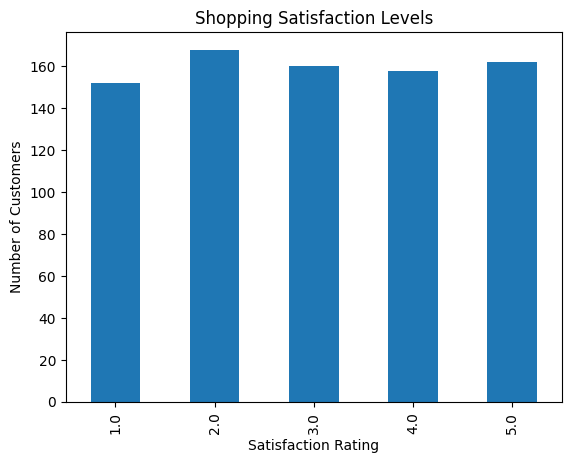

In [72]:
df['Shopping_Satisfaction'].value_counts().sort_index().plot(kind='bar')
plt.title('Shopping Satisfaction Levels')
plt.xlabel('Satisfaction Rating')
plt.ylabel('Number of Customers')
plt.show()

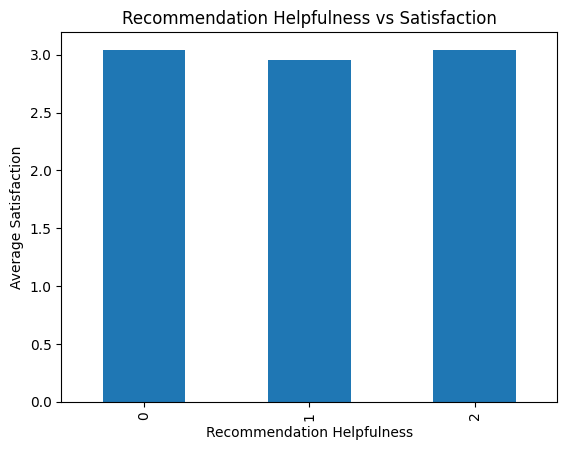

In [75]:
df.groupby('Recommendation_Helpfulness')['Shopping_Satisfaction'].mean().plot(kind='bar')
plt.title('Recommendation Helpfulness vs Satisfaction')
plt.xlabel('Recommendation Helpfulness')
plt.ylabel('Average Satisfaction')
plt.show()

In [76]:
numeric_df = df.select_dtypes(include=[np.number])

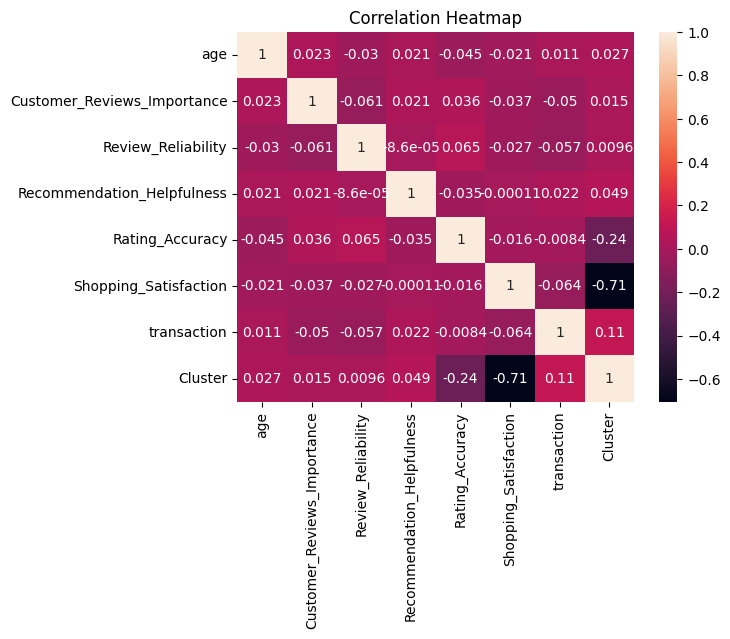

In [78]:
sns.heatmap(numeric_df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [79]:
df.to_csv('Amazon_Task_5_Visualization.csv', index=False)

In [83]:
df.to_csv('Amazon_Final_Project.csv', index=False)